# 🚀 Lab 43: Sentiment Analysis on EdTech Feedback

## 🎯 Learning Objectives
In this lab, you will build a complete sentiment analysis workflow for Educational Technology (EdTech) feedback. Think of this as teaching a computer to 'read' student and teacher comments to understand if they are happy or frustrated.

By the end of this lab, you will:
*   Understand sentiment analysis in the EdTech context.
*   Load and preprocess labeled feedback datasets.
*   Implement **TF-IDF vectorization** (turning words into numbers).
*   Build and train a **Logistic Regression classifier**.
*   Evaluate model performance using professional metrics (Accuracy, Precision, Recall, F1).
*   Predict sentiment for brand-new feedback examples.

## ⚙️ Environment Setup
### 💡 ELI10: What are we doing?
Before we start building, we need to gather our tools. Just like a chef needs specific knives and pans, a Data Scientist needs specific libraries (code packages) to handle data and build models.

We will install and import:
*   `pandas` & `numpy`: For handling tables and numbers.
*   `scikit-learn`: Our primary machine learning toolkit.
*   `matplotlib` & `seaborn`: For creating beautiful charts.

In [1]:
# Install and upgrade necessary libraries
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

import os
import re
import string
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)

# Suppress warnings for a cleaner output
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
%matplotlib inline
sns.set(style='whitegrid')

# Create project directories
for folder in ['data', 'models', 'results']:
    os.makedirs(folder, exist_ok=True)

print("✅ Environment setup complete. Directories created: data/, models/, results/")

✅ Environment setup complete. Directories created: data/, models/, results/


## 📊 Data Preparation
### 💡 ELI10: What are we doing?
To teach a computer, we need examples. We are creating a small 'dataset' of 40 comments. Half are positive (1) and half are negative (0). We save this to a file so we can treat it like a real-world project.

In [2]:
positive_feedback = [
    "This learning platform is amazing! My students love the interactive features.",
    "Great user interface and easy navigation. Highly recommend for educators.",
    "The video lessons are clear and engaging. Students show improved performance.",
    "Excellent customer support and regular updates. Very satisfied with the service.",
    "Interactive quizzes make learning fun and effective for my classroom.",
    "The analytics dashboard helps me track student progress efficiently.",
    "Love the collaborative features that allow students to work together.",
    "The mobile app works perfectly and students can learn anywhere.",
    "Content is well-structured and aligns with curriculum standards.",
    "The gamification elements keep students motivated and engaged.",
    "Easy to integrate with our existing school management system.",
    "The assessment tools are comprehensive and save me lots of time.",
    "Students enjoy the personalized learning paths and adaptive content.",
    "The platform is reliable and rarely experiences downtime.",
    "Great value for money compared to other educational platforms.",
    "The reporting features help me communicate progress to parents effectively.",
    "Students have shown significant improvement since using this platform.",
    "The content library is extensive and covers all required topics.",
    "User-friendly design makes it easy for both teachers and students.",
    "The platform adapts well to different learning styles and needs."
]

negative_feedback = [
    "The platform is too slow and crashes frequently during lessons.",
    "Very confusing interface. Students struggle to navigate the system.",
    "Poor customer service response time. Issues take weeks to resolve.",
    "The content is outdated and doesn't match current curriculum standards.",
    "Too expensive for the limited features provided. Not worth the cost.",
    "The mobile app is buggy and doesn't sync properly with the web version.",
    "Lack of interactive elements makes the lessons boring for students.",
    "The assessment tools are limited and don't provide detailed feedback.",
    "Difficult to integrate with our school's existing technology infrastructure.",
    "The platform lacks essential features that competitors offer.",
    "Students complain about the complicated login process and frequent logouts.",
    "The video quality is poor and audio often cuts out during presentations.",
    "Limited customization options for different grade levels and subjects.",
    "The analytics are basic and don't provide actionable insights.",
    "Frequent technical issues disrupt classroom activities and learning.",
    "The content is not engaging enough to hold student attention.",
    "Poor accessibility features for students with special needs.",
    "The platform doesn't work well with older devices in our school.",
    "Lack of offline functionality makes it unusable in areas with poor internet.",
    "The grading system is inflexible and doesn't match our school's requirements."
]

# Combine and label (1 for positive, 0 for negative)
data = pd.DataFrame({
    'feedback': positive_feedback + negative_feedback,
    'sentiment': [1]*20 + [0]*20
})

# Shuffle the dataset
df = data.sample(frac=1, random_state=42).reset_index(drop=True)
df.to_csv('data/edtech_feedback.csv', index=False)

print(f"Total entries: {len(df)}")
print(f"Positive: {len(df[df.sentiment==1])}, Negative: {len(df[df.sentiment==0])}")
display(df.head())

Total entries: 40
Positive: 20, Negative: 20


,feedback,sentiment
0,The platform adapts well to different learning...,1
1,Students have shown significant improvement si...,1
2,The reporting features help me communicate pro...,1
3,Lack of interactive elements makes the lessons...,0
4,Interactive quizzes make learning fun and effe...,1


## 🔍 Data Exploration
### 💡 ELI10: What are we doing?
Before modeling, we 'meet' our data. We look at how many characters are in the feedback and check if the groups are equal. This helps us ensure our 'teacher' (the model) has fair examples of both sides.

Dataset Shape: (40, 2)


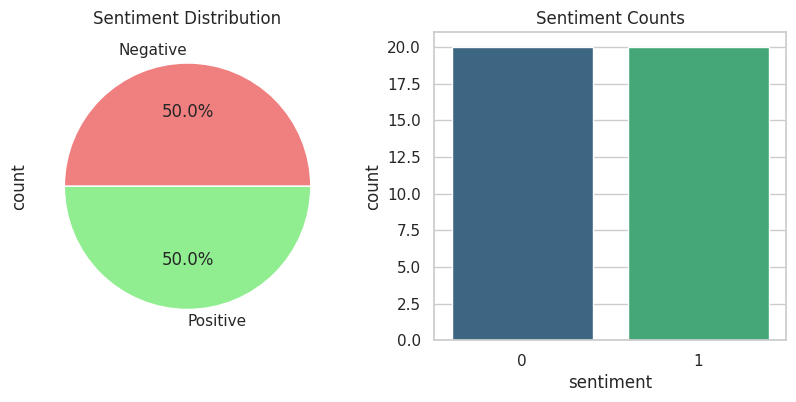

Avg Length: 67.92 | Min: 57 | Max: 80


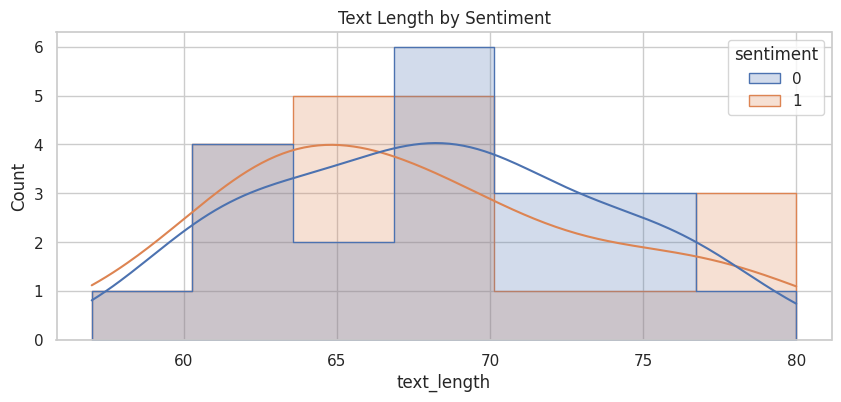

In [3]:
# 1. Basic Stats
print(f"Dataset Shape: {df.shape}")

# 2. Visualize Sentiment Distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['sentiment'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'], labels=['Negative', 'Positive'])
plt.title('Sentiment Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Sentiment Counts')
plt.savefig('results/sentiment_distribution.png')
plt.show()

# 3. Text Length Analysis
df['text_length'] = df['feedback'].apply(len)
print(f"Avg Length: {df['text_length'].mean():.2f} | Min: {df['text_length'].min()} | Max: {df['text_length'].max()}")

plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='text_length', hue='sentiment', kde=True, element='step')
plt.title('Text Length by Sentiment')
plt.savefig('results/text_length_analysis.png')
plt.show()

## 🧹 Text Preprocessing
### 💡 ELI10: What are we doing?
Computers get confused by punctuation like '!!!' or capital letters like 'Engaging' vs 'engaging'. We clean the text to make it simpler and more consistent.

In [4]:
def preprocess_text(text):
    text = text.lower() # Lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'\@\w+|\#','', text) # Remove mentions/hashtags
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra whitespace
    return text

sample = df['feedback'][0]
print(f"Original: {sample}")
print(f"Processed: {preprocess_text(sample)}")

df['processed_feedback'] = df['feedback'].apply(preprocess_text)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_feedback'], df['sentiment'],
    test_size=0.2, random_state=42, stratify=df['sentiment']
)

# Save splits
pd.concat([X_train, y_train], axis=1).to_csv('data/train_data.csv', index=False)
pd.concat([X_test, y_test], axis=1).to_csv('data/test_data.csv', index=False)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Original: The platform adapts well to different learning styles and needs.
Processed: the platform adapts well to different learning styles and needs
Train size: 32, Test size: 8


## 🧠 TF-IDF Vectorization
### 💡 ELI10: What are we doing?
We can't do math on words. **TF-IDF** (Term Frequency-Inverse Document Frequency) assigns a score to words based on how unique or important they are. This converts our sentences into a matrix of numbers.

In [5]:
vectorizer = TfidfVectorizer(max_features=1000, min_df=2, max_df=0.8, ngram_range=(1, 2), stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Save artifacts
joblib.dump(vectorizer, 'models/tfidf_vectorizer.pkl')
joblib.dump(X_train_tfidf, 'models/X_train_tfidf.pkl')
joblib.dump(X_test_tfidf, 'models/X_test_tfidf.pkl')

# Feature Analysis
features = vectorizer.get_feature_names_out()
print(f"Vocabulary size: {len(features)}")
print(f"Top 5 features: {features[:5]}")

# Display top 10 general importance
importance = np.asarray(X_train_tfidf.mean(axis=0)).ravel().argsort()[::-1]
print("Top 10 overall features:")
for i in range(10): print(f"- {features[importance[i]]}")

Vocabulary size: 35
Top 5 features: ['app' 'assessment' 'assessment tools' 'content' 'customer']
Top 10 overall features:
- students
- content
- platform
- features
- poor
- learning
- great
- lessons
- doesnt
- interactive


## 🤖 Logistic Regression Classifier
### 💡 ELI10: What are we doing?
Logistic Regression is like a smart scale. It looks at the words (the numbers from TF-IDF) and decides which way the scale tips: Positive or Negative.

Test Accuracy: 0.50
              precision    recall  f1-score   support

    Negative       0.50      0.50      0.50         4
    Positive       0.50      0.50      0.50         4

    accuracy                           0.50         8
   macro avg       0.50      0.50      0.50         8
weighted avg       0.50      0.50      0.50         8



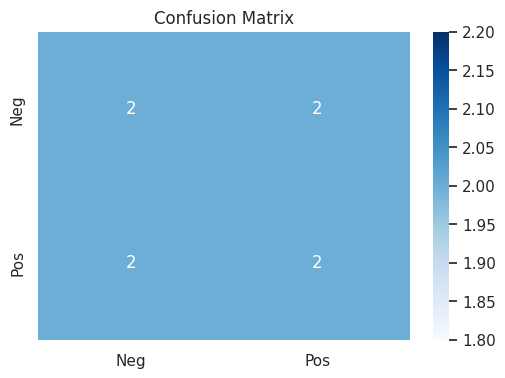

['models/logistic_classifier.pkl']

In [6]:
model = LogisticRegression(C=1.0, max_iter=1000, random_state=42, solver='liblinear')
model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:, 1]

# Basic Metrics
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.title('Confusion Matrix')
plt.savefig('results/model_performance.png')
plt.show()

joblib.dump(model, 'models/logistic_classifier.pkl')

## 📈 Comprehensive Model Evaluation
### 💡 ELI10: What are we doing?
Is the model truly good, or did it just get lucky? We check the **ROC Curve** (how well it separates classes) and other detailed stats like **Sensitivity** (how many actual positives did it catch?).

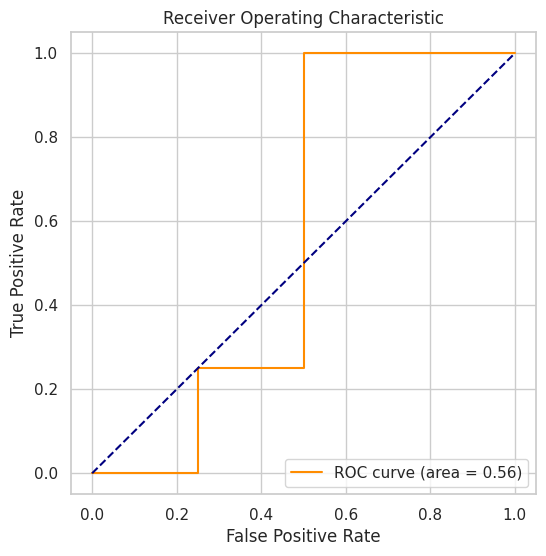

Top Features (Impact on Prediction):


,feature,coef,abs_coef
25,poor,-0.841211,0.841211
5,doesnt,-0.619999,0.619999
17,learning,0.609699,0.609699
13,great,0.587721,0.587721
3,content,0.555017,0.555017
19,limited,-0.516200,0.516200
28,schools,-0.477749,0.477749
8,easy,0.454132,0.454132
20,love,0.402808,0.402808
21,makes,-0.373661,0.373661


In [7]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.savefig('results/comprehensive_model_evaluation.png')
plt.show()

# Coefficient Analysis
coef_df = pd.DataFrame({'feature': features, 'coef': model.coef_[0]})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)
coef_df.to_csv('results/feature_importance.csv', index=False)
print("Top Features (Impact on Prediction):")
display(coef_df.head(10))

## 🧪 Predicting New Feedback
### 💡 ELI10: What are we doing?
Now for the fun part! We give the model sentences it has **never seen before** to see if it can correctly guess the sentiment.

In [8]:
def predict_sentiment(text):
    clean = preprocess_text(text)
    vec = vectorizer.transform([clean])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    label = 'Positive' if pred == 1 else 'Negative'
    return text, clean, label, prob[0], prob[1]

test_samples = [
    "The dashboard is intuitive and helps teachers monitor progress easily.",
    "Students keep getting logged out and the lessons freeze too often.",
    "The quiz system is useful but the interface could be more user-friendly.",
    "Excellent learning paths and engaging content for different skill levels.",
    "The app is unreliable on older tablets and wastes classroom time."
]

for ts in test_samples:
    o, c, l, p_neg, p_pos = predict_sentiment(ts)
    print(f"Text: {o}\nResult: {l} (Pos: {p_pos:.2f}, Neg: {p_neg:.2f})\n")

Text: The dashboard is intuitive and helps teachers monitor progress easily.
Result: Negative (Pos: 0.50, Neg: 0.50)

Text: Students keep getting logged out and the lessons freeze too often.
Result: Negative (Pos: 0.47, Neg: 0.53)

Text: The quiz system is useful but the interface could be more user-friendly.
Result: Negative (Pos: 0.50, Neg: 0.50)

Text: Excellent learning paths and engaging content for different skill levels.
Result: Positive (Pos: 0.64, Neg: 0.36)

Text: The app is unreliable on older tablets and wastes classroom time.
Result: Positive (Pos: 0.51, Neg: 0.49)



## ✅ Verification
We run automated checks to ensure all files were saved and the dataset meets the lab requirements.

In [9]:
files = [
    'data/edtech_feedback.csv', 'data/train_data.csv', 'data/test_data.csv',
    'models/tfidf_vectorizer.pkl', 'models/logistic_classifier.pkl', 'results/feature_importance.csv'
]
for f in files:
    assert os.path.exists(f), f"Error: {f} not found!"

assert len(df) == 40, "Dataset should have exactly 40 rows."
print("✅ Verification Success: All files exist and dataset size is correct.")

✅ Verification Success: All files exist and dataset size is correct.


## 🛠 Troubleshooting
*   **Vocabulary too small:** If `min_df` is too high, common words like 'platform' might be ignored. Try reducing it to 1.
*   **Low Accuracy:** With only 40 examples, the model might overfit. In real life, we would use thousands of examples.
*   **Errors in Prediction:** Ensure you apply the *same* `preprocess_text` function to new data as you did for training.

## 🏁 Conclusion
### 🌍 Real-World Importance
In EdTech, sentiment analysis allows companies to quickly find 'pain points' (like buggy apps) without reading 5,000 emails manually. It helps prioritize fixes that improve student learning.

### 📚 Key Takeaways
1.  **Preprocessing** makes text uniform.
2.  **TF-IDF** turns words into weighted mathematical importance.
3.  **Logistic Regression** is a fast and interpretable way to classify sentiment.
4.  **Evaluation** must include more than just accuracy (Precision/Recall/AUC).

**Optional Extension:** Try changing the `C` parameter in Logistic Regression to see how it affects the confusion matrix!